# Notebook A: Statistical & Visual Analysis of FOLIO Data

**Purpose:** Load data (exported CSV or pulled live from the FOLIO API), explore it,
clean it, and build visualizations that answer specific questions the FOLIO UI can't
answer on its own (trends, distributions, aggregate stats).

**How to use this notebook:** Each section below has a markdown cell explaining the
*question* being asked, followed by a code cell that answers it. Fill in the
`# TODO (FOLIO-specific)` spots with your own field names / endpoints — the
Python/pandas mechanics around them are already scaffolded.


## 1. Environment setup

Run this once per session. If a package is missing, uncomment the `pip install` line.


In [30]:
# !pip install pandas matplotlib seaborn requests

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Nicer default plot styling
sns.set_theme(style="whitegrid")


## 2. Login using shared notebook

In [31]:
%run folio_auth.ipynb

Login succeeded. Token retrieved.


## 3. Load data into a DataFrame

Two paths depending on your source:

- **From an export (CSV)** — e.g. output from the Lists app or Bulk Operations.
- **From a live API call** — using the `headers`/`base_url` from the login step.

Use whichever fits this notebook's purpose; delete the path you don't need.


In [32]:
# --- Path A: Load from an exported CSV ---
df = pd.read_csv("input/circ.csv")


# Placeholder so the notebook runs end-to-end before you wire in real data:
# df = pd.DataFrame({
#     "example_date": pd.date_range("2026-01-01", periods=10, freq="D"),
#     "example_count": range(10),
# })

df.head()


,User barcode,Item barcode,Object,Circ action,Date,Service point,Source,Description
0,2222123,32260007257178675,Loan,Closed loan,2026-08-02 16:57,Curbside Main Library,"Admin, CHoFOLIO",Item status: In transit.
1,2222123,32260007257178675,NaN,Checked in,2026-08-02 16:57,Curbside Main Library,"Admin, CHoFOLIO",Item status: In transit to MC Alton Circ.
2,2222123,32260007257178675,Notice,Send,2026-08-02 16:49,Curbside Main Library,System,Template: Checkout receipt. Triggering event: ...
3,2222123,"32260007257178675,32260007257178675",Notice,Send,2026-08-02 16:42,Curbside Main Library,System,Template: Overdue notice - long term. Triggeri...
4,2222123,32260007257178675,Loan,Checked out,2026-08-02 16:42,Curbside Main Library,"Admin, CHoFOLIO",Checked out to proxy: no.


## 4. Initial exploration

Before doing anything else, get a feel for the data: shape, types, missing values.


In [33]:
print(df.shape)
df.info()


(633, 8)
<class 'pandas.DataFrame'>
RangeIndex: 633 entries, 0 to 632
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   User barcode   633 non-null    str  
 1   Item barcode   594 non-null    str  
 2   Object         578 non-null    str  
 3   Circ action    633 non-null    str  
 4   Date           633 non-null    str  
 5   Service point  633 non-null    str  
 6   Source         631 non-null    str  
 7   Description    624 non-null    str  
dtypes: str(8)
memory usage: 39.7 KB


In [34]:
df.describe(include='all')


,User barcode,Item barcode,Object,Circ action,Date,Service point,Source,Description
count,633,594,578,633,633,633,631,624
unique,34,124,4,20,375,1,14,81
top,-,32261010002312,Request,Send,2024-04-16 12:31,Curbside Main Library,System,Type: Page.
freq,242,54,281,220,7,633,244,83


In [35]:
df.isnull().sum()


User barcode      0
Item barcode     39
Object           55
Circ action       0
Date              0
Service point     0
Source            2
Description       9
dtype: int64

## 5. Cleaning

Common cleanup steps — uncomment/adjust as needed for your actual columns.


In [36]:
# Convert date-like columns explicitly (don't assume pandas guessed correctly)
# df['example_date'] = pd.to_datetime(df['example_date'])

# Drop rows missing a required field, OR fill with a sensible default — decide per column
# df = df.dropna(subset=['important_column'])
# df['optional_column'] = df['optional_column'].fillna('Unknown')

# Rename columns for readability if the raw API/export names are cryptic
# df = df.rename(columns={'old_name': 'new_name'})


## 6. Transform for analysis

This is where "statistics" happens: aggregating, filtering, reshaping.


In [37]:
# Example: counts grouped by a category over time
# grouped = df.groupby([pd.Grouper(key='example_date', freq='M')])['example_count'].sum()

# Example: filter to a subset
# filtered = df[df['example_count'] > 5]

# Example: pivot for a summary table
# pivot = df.pivot_table(index='example_date', values='example_count', aggfunc='sum')


## 7. Visualize

One question per chart. Add a markdown cell above each plot stating the question
it answers, e.g. "How did X change over time?" or "What's the distribution of Y?"


KeyError: 'example_date'

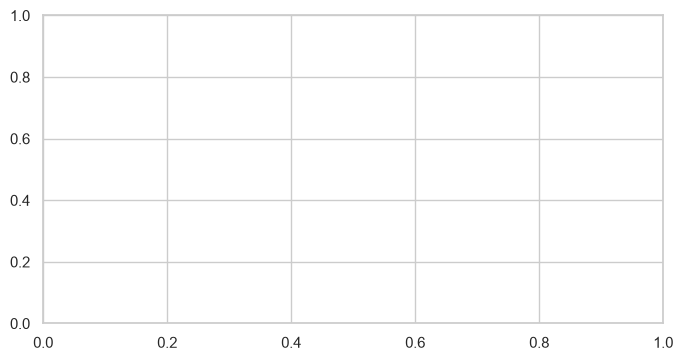

In [38]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df['example_date'], df['example_count'], marker='o')
ax.set_title("Example: replace with your real question")
ax.set_xlabel("Date")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Example: distribution / histogram
# sns.histplot(df['example_count'], bins=10)
# plt.title("Distribution of example_count")
# plt.show()


## 8. Summary / next steps

Use a final markdown cell to state the key findings in plain language — this is the
"report" part of the notebook, separate from the code that produced it.

- Finding 1: ...
- Finding 2: ...

**Possible next steps:** export cleaned data for reuse in Notebook B (joining with
external sources), or save this notebook's output for repeatable reporting (Notebook C).
